# SET UP

Load data from publication data and rawpublication data

In [2]:
import pandas as pd

publications = pd.read_csv('./data/publications.csv')
# Filter out publications after 2025
publications = publications[publications.year < 2026]
# Filter out publications that are NOT approved
publications = publications[publications.status == "APPROVED"]
rawpublications = pd.read_csv('./data/rawpublications.csv')

In [3]:
all_pubs = pd.read_csv('./data/publications.csv')
all_pubs = all_pubs[all_pubs.year < 2026]
all_pubs.status.value_counts() / all_pubs.shape[0] * 100

status
APPROVED                 74.349442
SUBMITTED                 8.488228
REFERENCE_ONLY            6.381660
REJECTED                  5.018587
DELETED                   3.097893
PRODUCED_BY_CHAMELEON     2.664188
Name: count, dtype: float64

## HOW DO WE IDENTIFY PUBLICATIONS AND WHAT DOES THIS LOOK LIKE ACROSS YEARS

In [4]:
# Merge publications with rawpublication (sources)
pubsources = rawpublications.merge(publications, left_on='publication_id', right_on='id', suffixes=['_rp', '_p'],)
pubsources.to_csv('./data/merged_pubs.csv', index=False)
pubsources.id_p.nunique()

1200

In [5]:
def categorize_verification(row):
    """
    Categorize how Chameleon use was verified:
    - 'Citation': cites_chameleon=1
    - 'Acknowledgment only': cites_chameleon=0, acknowledges_chameleon=1
    - 'User attestation': neither flag set (verified via user statement)
    """
    cites = row['cites_chameleon'] == 1
    acks = row['acknowledges_chameleon'] == 1
    
    if cites:
        return 'Citation'
    elif acks:
        return 'Acknowledgment only'
    else:
        return 'User attestation'

pub_level = pubsources.groupby('id_p').agg({
    'cites_chameleon': 'max',
    'acknowledges_chameleon': 'max',
    'year_p': 'max'
}).reset_index()


pub_level['categorization'] = pub_level.apply(categorize_verification, axis=1)
print(pub_level.categorization.value_counts() / pub_level.id_p.nunique())
pub_level.categorization.value_counts()

categorization
Citation               0.536667
Acknowledgment only    0.310833
User attestation       0.152500
Name: count, dtype: float64


categorization
Citation               644
Acknowledgment only    373
User attestation       183
Name: count, dtype: int64

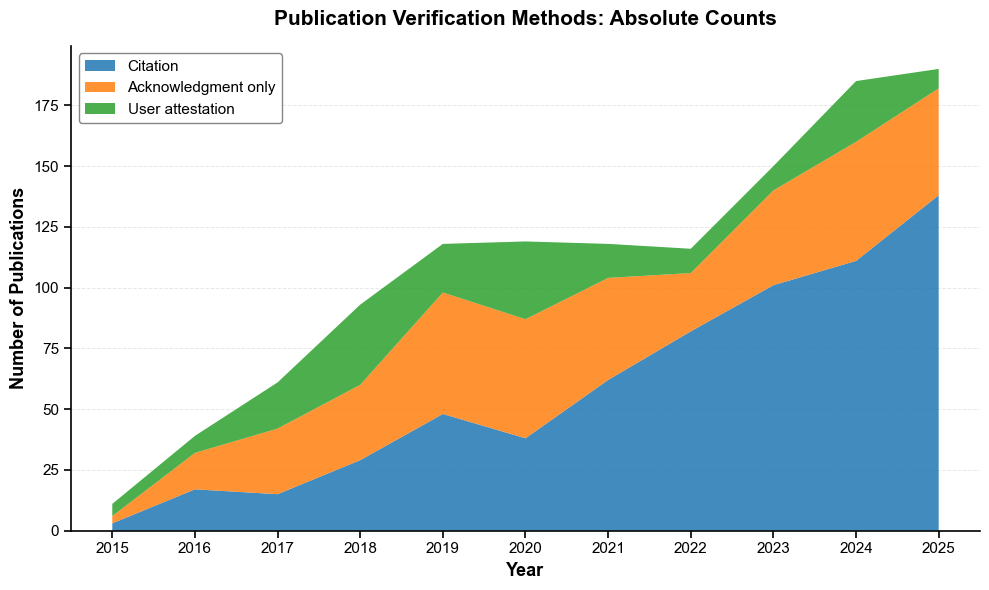

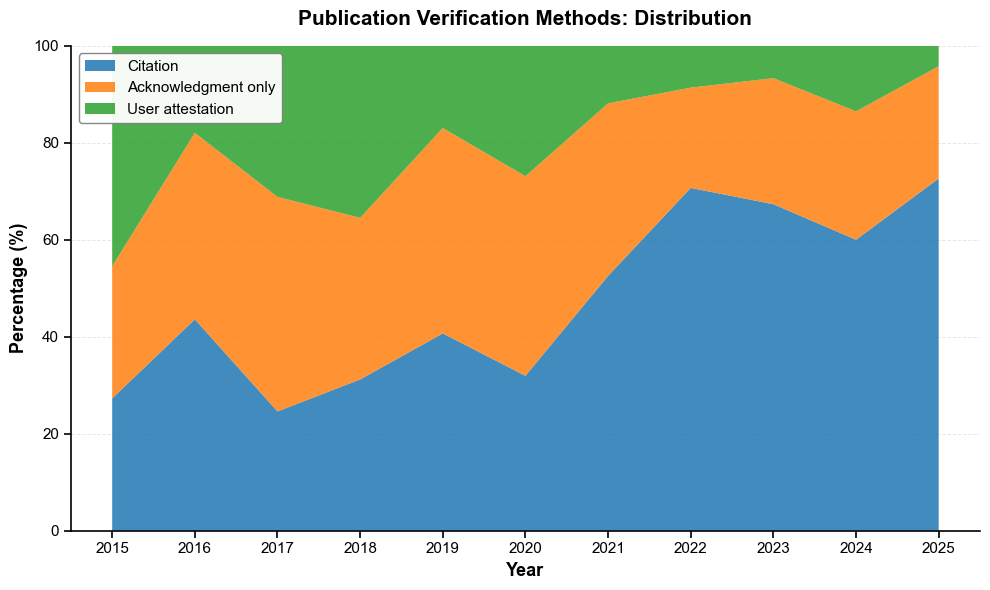

Figures saved successfully!


In [ ]:
import matplotlib.pyplot as plt

# Group by year and verification method
yearly_counts = pub_level.groupby(['year_p', 'categorization']).size().unstack(fill_value=0)

# Ensure we have all categories (in case some years are missing certain methods)
categories = ['Citation', 'Acknowledgment only', 'User attestation']
for cat in categories:
    if cat not in yearly_counts.columns:
        yearly_counts[cat] = 0

yearly_counts = yearly_counts[categories]  # Reorder columns

# Calculate percentages
yearly_percentages = yearly_counts.div(yearly_counts.sum(axis=1), axis=0) * 100

# Color scheme
# colors = {
#     'Citation': '#2E86AB',
#     'Acknowledgment only': '#A23B72',
#     'User attestation': '#C73E1D'
# }

years = yearly_counts.index

# Set publication-quality style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']

# ============================================================================
# Figure 1a: Absolute Counts
# ============================================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))

ax1.stackplot(years, 
              yearly_counts['Citation'],
              yearly_counts['Acknowledgment only'],
              yearly_counts['User attestation'],
              labels=categories,
            #   colors=[colors[cat] for cat in categories],
              alpha=0.85)

ax1.set_ylabel('Number of Publications', fontsize=13, fontweight='bold')
ax1.set_xlabel('Year', fontsize=13, fontweight='bold')
ax1.set_title('Publication Verification Methods: Absolute Counts', 
              fontsize=15, fontweight='bold', pad=15)

# Improve legend
ax1.legend(loc='upper left', frameon=True, fontsize=11, 
           framealpha=0.95, edgecolor='gray')

# Grid styling
ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax1.set_axisbelow(True)

# Spine styling
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(1.2)
ax1.spines['bottom'].set_linewidth(1.2)

# Tick styling
ax1.tick_params(axis='both', which='major', labelsize=11, length=5, width=1.2)

# Set x-axis to show only integer years
ax1.set_xticks(years)
ax1.set_xticklabels([int(y) for y in years])

plt.tight_layout()
plt.savefig('figure1a_verification_counts.svg', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

# ============================================================================
# Figure 1b: Percentages
# ============================================================================
fig2, ax2 = plt.subplots(figsize=(10, 6))

ax2.stackplot(years,
              yearly_percentages['Citation'],
              yearly_percentages['Acknowledgment only'],
              yearly_percentages['User attestation'],
              labels=categories,
            #   colors=[colors[cat] for cat in categories],
              alpha=0.85)

ax2.set_ylabel('Percentage (%)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Year', fontsize=13, fontweight='bold')
ax2.set_title('Publication Verification Methods: Distribution', 
              fontsize=15, fontweight='bold', pad=15)
ax2.set_ylim(0, 100)

# Improve legend
ax2.legend(loc='upper left', frameon=True, fontsize=11, 
           framealpha=0.95, edgecolor='gray')

# Grid styling
ax2.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax2.set_axisbelow(True)

# Spine styling
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(1.2)
ax2.spines['bottom'].set_linewidth(1.2)

# Tick styling
ax2.tick_params(axis='both', which='major', labelsize=11, length=5, width=1.2)

# Set x-axis to show only integer years
ax2.set_xticks(years)
ax2.set_xticklabels([int(y) for y in years])

plt.tight_layout()
plt.savefig('figure1b_verification_percentages.svg', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("Figures saved successfully!")

## SOURCE ANALYSIS

In [7]:
approved_mask = rawpublications.publication_id.isin(publications.id.values)
deduped = rawpublications[approved_mask].drop_duplicates(
    subset=['publication_id', 'name'],
    keep = 'first'
)
source_pivot = deduped.pivot_table(
    index='publication_id',
    columns='name',
    values='id',
    aggfunc='count',
    fill_value=0
)
source_pivot = (source_pivot > 0).astype(int)
source_pivot

name,google_scholar,openalex,science_direct,scopus,semantic_scholar,user_reported
publication_id,,,,,,
1,1,0,0,1,1,1
2,1,0,0,1,1,1
3,1,0,0,1,1,1
4,1,0,0,1,1,1
5,1,0,0,1,1,1
...,...,...,...,...,...,...
4105,1,0,0,0,0,0
4106,1,0,0,0,0,0
4107,1,0,0,0,0,0


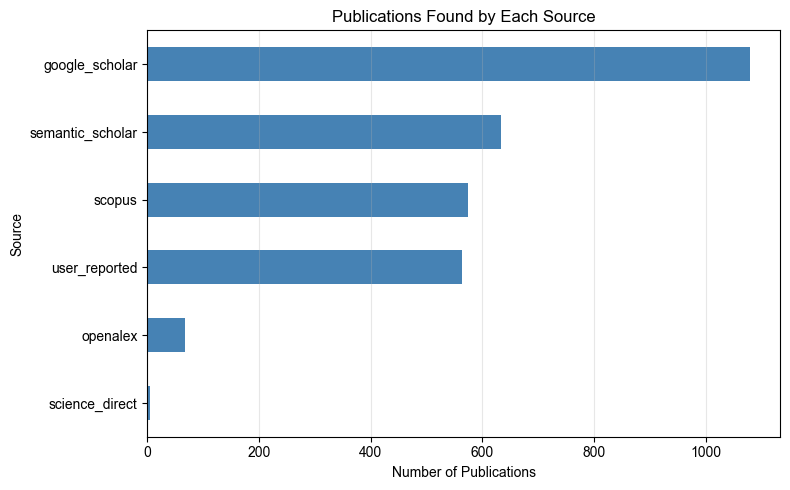

name
science_direct         5
openalex              67
user_reported        563
scopus               574
semantic_scholar     634
google_scholar      1079
dtype: int64

In [8]:
import matplotlib.pyplot as plt

# Count publications per source
source_counts = source_pivot.sum().sort_values(ascending=True)

# Create bar plot
plt.figure(figsize=(8, 5))
source_counts.plot(kind='barh', color='steelblue')
plt.xlabel('Number of Publications')
plt.ylabel('Source')
plt.title('Publications Found by Each Source')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('source_bar_chart.svg', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
source_counts

In [9]:
# Count how many sources found each publication
num_sources_per_pub = source_pivot.sum(axis=1)

# Count publications with more than 1 source
pubs_multiple_sources = (num_sources_per_pub > 1).sum()

print(f"Publications found by more than 1 source: {pubs_multiple_sources / source_pivot.index.nunique()}")

Publications found by more than 1 source: 0.62


In [10]:
# For each source, find publications found ONLY by that source
unique_by_source = {}

for source in source_pivot.columns:
    # Publications where this source = 1 and all others = 0
    only_this_source = (source_pivot[source] == 1) & (source_pivot.sum(axis=1) == 1)
    unique_by_source[source] = only_this_source.sum()

# Display results
for source, count in unique_by_source.items():
    print(f"{source:20s}: {count:4d} unique publications")
    print()

google_scholar      :  348 unique publications

openalex            :    1 unique publications

science_direct      :    1 unique publications

scopus              :    6 unique publications

semantic_scholar    :    4 unique publications

user_reported       :   96 unique publications



In [11]:
pub_ids = source_pivot[(source_pivot.google_scholar == 1) & (source_pivot.sum(axis=1) == 1)].index.values
pubsources[pubsources.publication_id.isin(pub_ids)].groupby(['publication_id', 'publication_type_p']).size().reset_index().publication_type_p.value_counts()

publication_type_p
conference paper          141
phd thesis                 91
journal article            34
ms thesis                  30
preprint                   28
thesis                      5
poster                      5
book chapter                4
tech report                 3
conference poster           1
tutorial                    1
PhD Oral Qualifier          1
Poster                      1
Thesis                      1
reproducibility report      1
software                    1
Name: count, dtype: int64

In [43]:
pub_ids = source_pivot[(source_pivot.user_reported == 1) & (source_pivot.sum(axis=1) == 1)].index.values
pubsources[pubsources.publication_id.isin(pub_ids)].groupby(['publication_id', 'publication_type_p']).size().reset_index().publication_type_p.value_counts()

publication_type_p
conference paper     54
journal article      18
preprint             11
presentation          3
software              2
ms thesis             1
conference talk       1
news article          1
patent                1
short talk            1
workshop report       1
conference poster     1
report                1
Name: count, dtype: int64

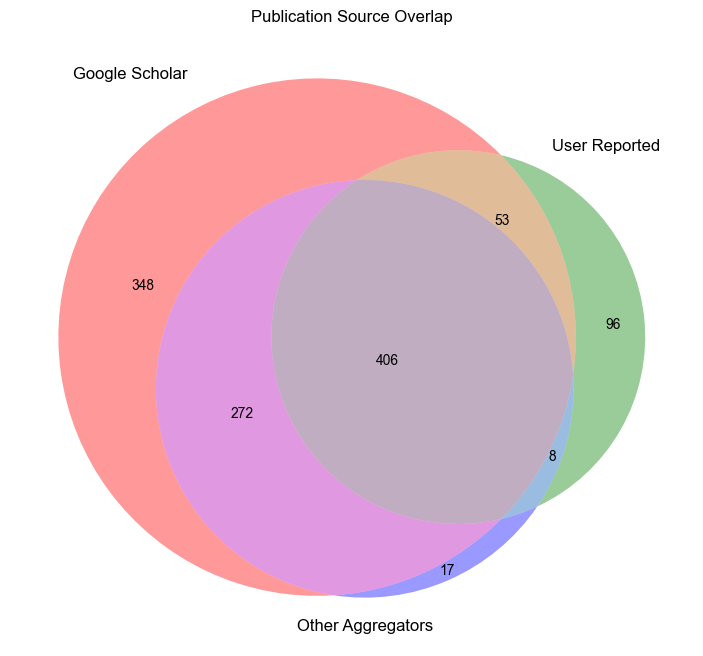

In [14]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# Create combined aggregator source column
aggregators = ['scopus', 'semantic_scholar', 'science_direct', 'openalex']
source_pivot['aggregators'] = (source_pivot[aggregators].sum(axis=1) > 0).astype(int)

# Calculate overlaps for Venn diagram
only_gs = ((source_pivot['google_scholar'] == 1) & 
           (source_pivot['user_reported'] == 0) & 
           (source_pivot['aggregators'] == 0)).sum()

only_user = ((source_pivot['google_scholar'] == 0) & 
             (source_pivot['user_reported'] == 1) & 
             (source_pivot['aggregators'] == 0)).sum()

only_agg = ((source_pivot['google_scholar'] == 0) & 
            (source_pivot['user_reported'] == 0) & 
            (source_pivot['aggregators'] == 1)).sum()

gs_user = ((source_pivot['google_scholar'] == 1) & 
           (source_pivot['user_reported'] == 1) & 
           (source_pivot['aggregators'] == 0)).sum()

gs_agg = ((source_pivot['google_scholar'] == 1) & 
          (source_pivot['user_reported'] == 0) & 
          (source_pivot['aggregators'] == 1)).sum()

user_agg = ((source_pivot['google_scholar'] == 0) & 
            (source_pivot['user_reported'] == 1) & 
            (source_pivot['aggregators'] == 1)).sum()

all_three = ((source_pivot['google_scholar'] == 1) & 
             (source_pivot['user_reported'] == 1) & 
             (source_pivot['aggregators'] == 1)).sum()

# Create Venn diagram
plt.figure(figsize=(10, 8))
venn3(subsets=(only_gs, only_user, gs_user, only_agg, gs_agg, user_agg, all_three),
      set_labels=('Google Scholar', 'User Reported', 'Other Aggregators'))
plt.title('Publication Source Overlap')
plt.savefig('venn_diagram.svg', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

In [47]:
# Check overlap between the aggregator sources
aggregator_sources = ['scopus', 'semantic_scholar', 'openalex', 'science_direct']

print("Publications found by each aggregator source:")
for source in aggregator_sources:
    count = source_pivot[source].sum()
    print(f"  {source:20s}: {count:4d}")

print("\nUnique publications found ONLY by each aggregator:")
for source in aggregator_sources:
    # Publications where this source = 1 and all other aggregators = 0
    other_aggs = [s for s in aggregator_sources if s != source]
    only_this = (source_pivot[source] == 1)
    for other in other_aggs:
        only_this = only_this & (source_pivot[other] == 0)
    unique_count = only_this.sum()
    print(f"  {source:20s}: {unique_count:4d}")

print("\nPublications found by multiple aggregators:")
# Count how many aggregator sources found each publication
num_agg_sources = source_pivot[aggregator_sources].sum(axis=1)
multiple_aggs = (num_agg_sources > 1).sum()
print(f"  Found by 2+ aggregators: {multiple_aggs}")

# Show distribution
print("\nDistribution of publications by number of aggregator sources:")
for i in range(5):
    count = (num_agg_sources == i).sum()
    if count > 0:
        print(f"  {i} aggregators: {count:4d}")

print("\nOverlap between Scopus and Semantic Scholar")
both = ((source_pivot['scopus'] == 1) & (source_pivot['semantic_scholar'] == 1)).sum()
only_scopus = ((source_pivot['scopus'] == 1) & (source_pivot['semantic_scholar'] == 0)).sum()
only_semantic = ((source_pivot['scopus'] == 0) & (source_pivot['semantic_scholar'] == 1)).sum()
either = ((source_pivot['scopus'] == 1) | (source_pivot['semantic_scholar'] == 1)).sum()

print(f"  Scopus only:            {only_scopus}")
print(f"  Semantic Scholar only:  {only_semantic}")
print(f"  Both:                   {both}")
print(f"  Either (union):         {either}")
print(f"  Overlap rate:           {both / either:.1%}")

Publications found by each aggregator source:
  scopus              :  574
  semantic_scholar    :  634
  openalex            :   67
  science_direct      :    5

Unique publications found ONLY by each aggregator:
  scopus              :   55
  semantic_scholar    :  116
  openalex            :    5
  science_direct      :    1

Publications found by multiple aggregators:
  Found by 2+ aggregators: 526

Distribution of publications by number of aggregator sources:
  0 aggregators:  497
  1 aggregators:  177
  2 aggregators:  476
  3 aggregators:   49
  4 aggregators:    1

Overlap between Scopus and Semantic Scholar
  Scopus only:            63
  Semantic Scholar only:  123
  Both:                   511
  Either (union):         697
  Overlap rate:           73.3%


# Publication Type

In [17]:
publications.publication_type.unique()

array(['conference paper', 'journal article', 'ms thesis', 'software',
       'preprint', 'book chapter', 'tech report', 'poster',
       'conference talk', 'presentation', 'news article', 'phd thesis',
       'conference poster', 'patent', 'short talk', 'workshop report',
       'PhD Oral Qualifier', 'book', 'thesis', 'tutorial', 'report',
       'PhD Thesis', 'Poster', 'Thesis',
       'Demonstration Preliminary Abstract', 'reproducibility report'],
      dtype=object)

In [18]:
type_categories = {
    'conference paper': ['conference paper','conference short paper','conference article','workshop paper','workshop report'],
    'journal article': ['journal article'],
    'thesis/dissertation': ['phd thesis','ms thesis','thesis','PhD Thesis','phd dissertation','Thesis','PhD Oral Qualifier'],
    'self-published': ['preprint','report','tech report'],
    'other': ['news article','patent','presentation','software','book chapter','book','conference talk','tutorial','short talk','poster','Poster','conference poster','reproducibility report','Demonstration Preliminary Abstract']
}

# Create reverse mapping from individual type to category
type_mapping = {}
for category, types in type_categories.items():
    for pub_type in types:
        type_mapping[pub_type] = category

# Apply the mapping
publications['pub_category'] = publications['publication_type'].map(type_mapping)

# Check for any unmapped types
unmapped = publications[publications['pub_category'].isna()]['publication_type'].unique()
if len(unmapped) > 0:
    print("Unmapped publication types:")
    print(unmapped)

# Show the breakdown
print("\nPublication breakdown by category:")
print(publications['pub_category'].value_counts() / publications.id.nunique())


Publication breakdown by category:
pub_category
conference paper       0.552500
journal article        0.202500
thesis/dissertation    0.118333
self-published         0.093333
other                  0.033333
Name: count, dtype: float64


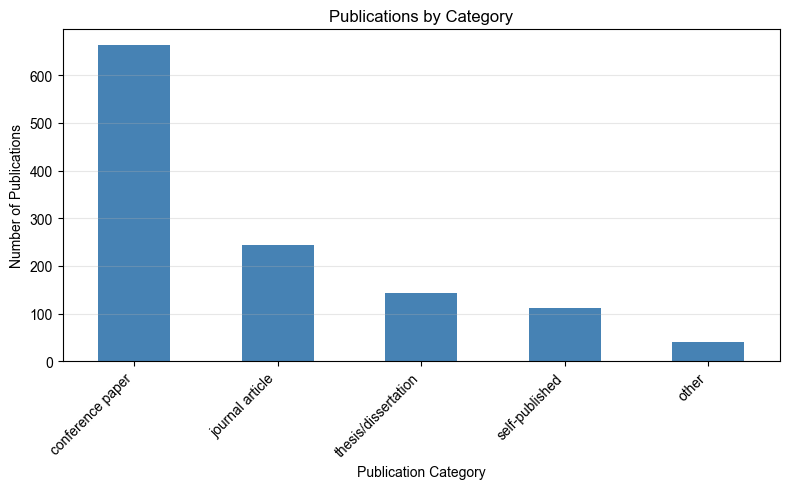

pub_category
conference paper       663
journal article        243
thesis/dissertation    142
self-published         112
other                   40
Name: count, dtype: int64

In [22]:
import matplotlib.pyplot as plt

# Count publications per category
category_counts = publications['pub_category'].value_counts()

# Create bar chart
plt.figure(figsize=(8, 5))
category_counts.plot(kind='bar', color='steelblue')
plt.xlabel('Publication Category')
plt.ylabel('Number of Publications')
plt.title('Publications by Category')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('pub_categories.svg', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
category_counts

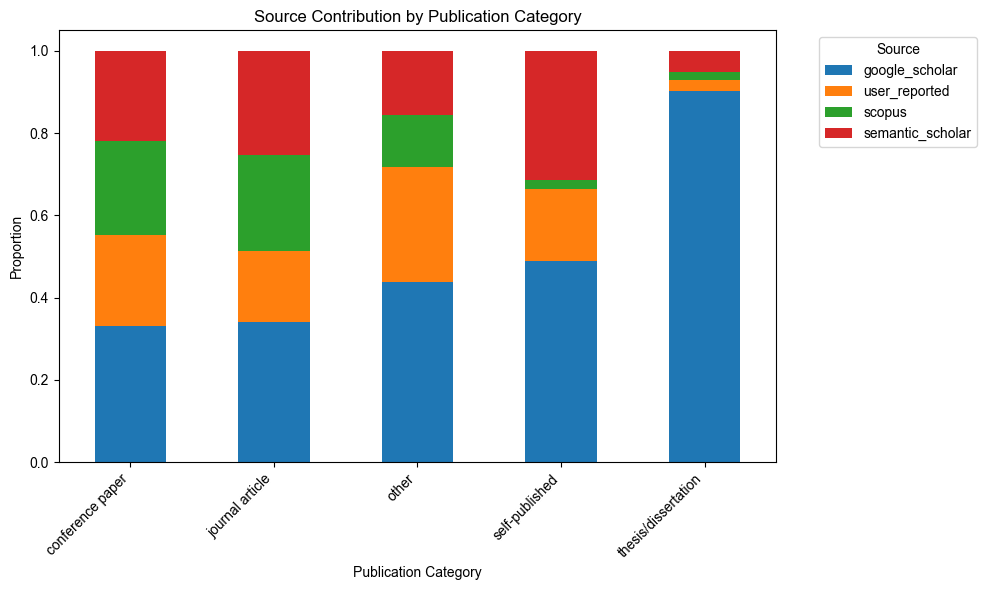

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Merge source_pivot with publications to get pub_category for each publication
pubs_with_sources = publications.set_index('id').join(source_pivot, how='inner')

# For each source, calculate the breakdown by pub_category
sources_to_plot = ['google_scholar', 'user_reported', 'scopus', 'semantic_scholar']
category_by_source = {}

for source in sources_to_plot:
    # Get publications found by this source
    source_pubs = pubs_with_sources[pubs_with_sources[source] == 1]
    # Count by category
    category_by_source[source] = source_pubs['pub_category'].value_counts()

# Create DataFrame for plotting
category_df = pd.DataFrame(category_by_source).fillna(0)

# Calculate proportions - divide each ROW by its sum (proportion within category)
category_proportions = category_df.div(category_df.sum(axis=1), axis=0)

# Create stacked bar chart
category_proportions.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Publication Category')
plt.ylabel('Proportion')
plt.title('Source Contribution by Publication Category')
plt.legend(title='Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('pub_categories_by_source.svg', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

In [24]:
category_proportions

,google_scholar,user_reported,scopus,semantic_scholar
pub_category,,,,
conference paper,0.332219,0.221293,0.228540,0.217949
journal article,0.341693,0.170846,0.233542,0.253918
other,0.437500,0.281250,0.125000,0.156250
self-published,0.490000,0.175000,0.020000,0.315000
thesis/dissertation,0.902597,0.025974,0.019481,0.051948


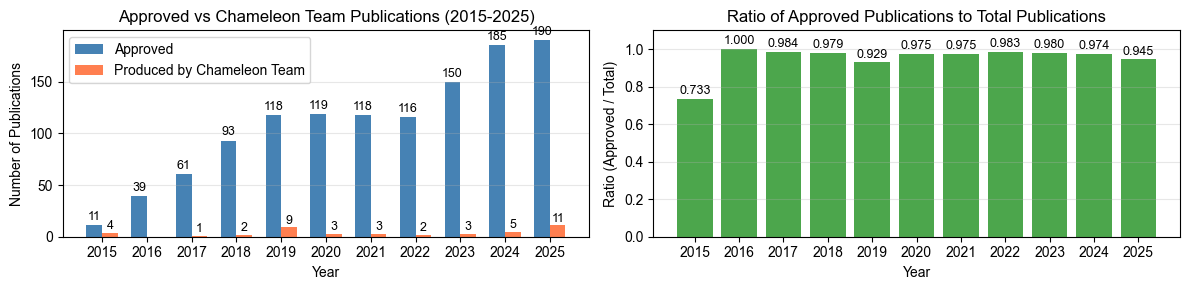

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('./data/publications.csv')

# Filter to years 2015-2025
df_filtered = df[(df['year'] >= 2015) & (df['year'] <= 2025)]

# Count approved and team publications by year
approved_by_year = df_filtered[df_filtered['status'] == 'APPROVED'].groupby('year').size()
team_by_year = df_filtered[df_filtered['status'] == 'PRODUCED_BY_CHAMELEON'].groupby('year').size()

# Create a complete year range and fill missing values with 0
years = range(2015, 2026)
approved_counts = [approved_by_year.get(year, 0) for year in years]
team_counts = [team_by_year.get(year, 0) for year in years]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

# Top plot: Side-by-side bar chart
x = list(years)
width = 0.35
x_pos = range(len(x))

ax1.bar([i - width/2 for i in x_pos], approved_counts, width, label='Approved', color='steelblue')
ax1.bar([i + width/2 for i in x_pos], team_counts, width, label='Produced by Chameleon Team', color='coral')

# Add value labels on bars
for i, (approved, team) in enumerate(zip(approved_counts, team_counts)):
    ax1.text(i - width/2, approved + 2, str(approved), ha='center', va='bottom', fontsize=9)
    if team > 0:
        ax1.text(i + width/2, team + 0.2, str(team), ha='center', va='bottom', fontsize=9)

ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Publications')
ax1.set_title('Approved vs Chameleon Team Publications (2015-2025)')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Bottom plot: Ratio bar chart (Approved / Total)
ratios = [approved/(approved + team) if (approved + team) > 0 else 0 
          for team, approved in zip(team_counts, approved_counts)]
bars = ax2.bar(x_pos, ratios, color='green', alpha=0.7)

# Add value labels on bars
for i, r in enumerate(ratios):
    if r > 0:
        ax2.text(i, r + 0.01, f'{r:.3f}', ha='center', va='bottom', fontsize=9)

ax2.set_xlabel('Year')
ax2.set_ylabel('Ratio (Approved / Total)')
ax2.set_title('Ratio of Approved Publications to Total Publications')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()